Cantidad de puntos cercanos (FB): 87
Tiempo Fuerza Bruta: 0.007176363999860769
Punto más cercano: (4982, 5035) Distancia: 39.35733730830886

--- BÚSQUEDA CON QUADTREE ---
Cantidad de puntos encontrados (QT): 87
Tiempo Quadtree: 0.0006829229996583308

¿Resultados iguales?: True


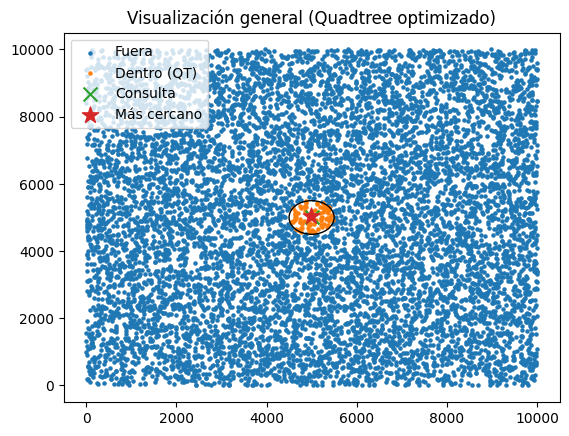

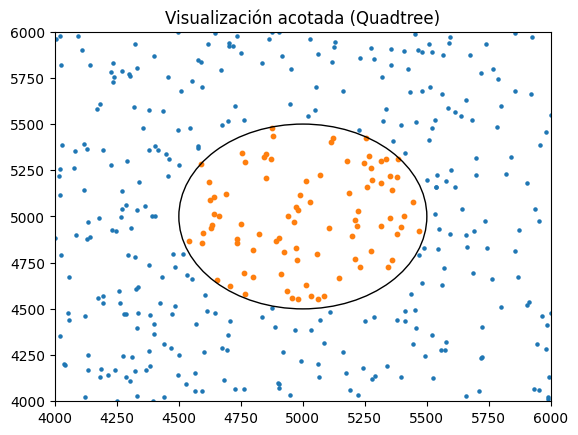


Tamaño: 5
Fuerza bruta: 0.00000347
Quadtree:     0.00001327
➡️ Gana Fuerza Bruta

Tamaño: 50
Fuerza bruta: 0.00003625
Quadtree:     0.00006011
➡️ Gana Fuerza Bruta

Tamaño: 100
Fuerza bruta: 0.00007176
Quadtree:     0.00008301
➡️ Gana Fuerza Bruta

Tamaño: 300
Fuerza bruta: 0.00021853
Quadtree:     0.00010239
➡️ Gana Quadtree

Tamaño: 600
Fuerza bruta: 0.00044924
Quadtree:     0.00013853
➡️ Gana Quadtree

Tamaño: 1000
Fuerza bruta: 0.00082777
Quadtree:     0.00017583
➡️ Gana Quadtree

Tamaño: 2000
Fuerza bruta: 0.00148133
Quadtree:     0.00020123
➡️ Gana Quadtree

Tamaño: 5000
Fuerza bruta: 0.00377686
Quadtree:     0.00038711
➡️ Gana Quadtree

Tamaño: 10000
Fuerza bruta: 0.00570838
Quadtree:     0.00046767
➡️ Gana Quadtree


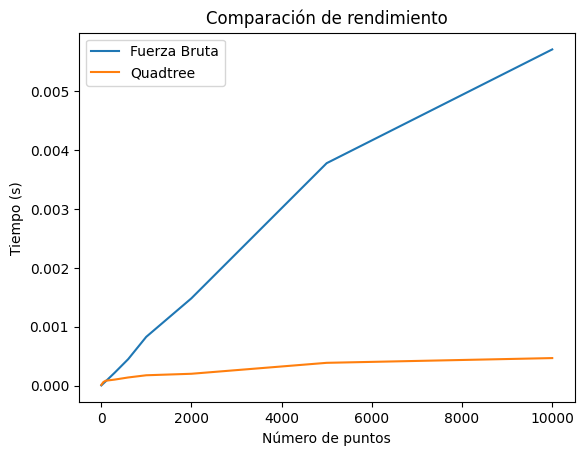

In [ ]:
# =========================================
# IMPORTS
# =========================================
import random
import math
import matplotlib.pyplot as plt
import time

# =========================================
# CONFIGURACIÓN
# =========================================
k = 2
consulta = (5000, 5000)
radio = 500

num_puntos = 10000
puntos = [tuple(random.randint(0, 10000) for _ in range(k)) for _ in range(num_puntos)]

# =========================================
# DISTANCIA
# =========================================
def distancia(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

# =========================================
# FUERZA BRUTA (CON TIEMPO)
# =========================================
inicio_fb = time.perf_counter()

puntos_cercanos = [p for p in puntos if distancia(p, consulta) <= radio]

tiempo_fb_real = time.perf_counter() - inicio_fb

min_dist = float("inf")
mas_cercano = None

for p in puntos:
    d = distancia(p, consulta)
    if d < min_dist:
        min_dist = d
        mas_cercano = p

print("Cantidad de puntos cercanos (FB):", len(puntos_cercanos))
print("Tiempo Fuerza Bruta:", tiempo_fb_real)
print("Punto más cercano:", mas_cercano, "Distancia:", min_dist)

# =========================================
# QUADTREE
# =========================================
CAPACIDAD = 4

class Rectangulo:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y
        self.w = w
        self.h = h

    def contiene(self, punto):
        return (self.x <= punto[0] <= self.x + self.w and
                self.y <= punto[1] <= self.y + self.h)

    def intersecta_circulo(self, centro, radio):
        x_cercano = max(self.x, min(centro[0], self.x + self.w))
        y_cercano = max(self.y, min(centro[1], self.y + self.h))
        return distancia((x_cercano, y_cercano), centro) <= radio

class Quadtree:
    def __init__(self, limite):
        self.limite = limite
        self.puntos = []
        self.dividido = False

    def subdividir(self):
        x, y, w, h = self.limite.x, self.limite.y, self.limite.w, self.limite.h

        self.ne = Quadtree(Rectangulo(x + w/2, y, w/2, h/2))
        self.no = Quadtree(Rectangulo(x, y, w/2, h/2))
        self.se = Quadtree(Rectangulo(x + w/2, y + h/2, w/2, h/2))
        self.so = Quadtree(Rectangulo(x, y + h/2, w/2, h/2))

        self.dividido = True

        # REPARTIR LOS PUNTOS A LOS HIJOS
        puntos_antiguos = self.puntos
        self.puntos = []

        for p in puntos_antiguos:
            (self.ne.insertar(p) or
             self.no.insertar(p) or
             self.se.insertar(p) or
             self.so.insertar(p))

    def insertar(self, punto):
        if not self.limite.contiene(punto):
            return False

        if len(self.puntos) < CAPACIDAD and not self.dividido:
            self.puntos.append(punto)
            return True

        if not self.dividido:
            self.subdividir()

        return (self.ne.insertar(punto) or
                self.no.insertar(punto) or
                self.se.insertar(punto) or
                self.so.insertar(punto))

    def buscar(self, centro, radio, encontrados):
        # 1. Si no intersecta → descartar nodo completo
        if not self.limite.intersecta_circulo(centro, radio):
            return

        # 2. Si es hoja → revisar puntos
        if not self.dividido:
            for p in self.puntos:
                if distancia(p, centro) <= radio:
                    encontrados.append(p)
            return

        # 3. Si está dividido → bajar a hijos
        self.ne.buscar(centro, radio, encontrados)
        self.no.buscar(centro, radio, encontrados)
        self.se.buscar(centro, radio, encontrados)
        self.so.buscar(centro, radio, encontrados)

# Construcción del árbol
limite = Rectangulo(0, 0, 10000, 10000)
qt = Quadtree(limite)

for p in puntos:
    qt.insertar(p)

# =========================================
# BÚSQUEDA CON QUADTREE
# =========================================
encontrados_qt = []
inicio_qt = time.perf_counter()

qt.buscar(consulta, radio, encontrados_qt)

tiempo_qt_real = time.perf_counter() - inicio_qt

print("\n--- BÚSQUEDA CON QUADTREE ---")
print("Cantidad de puntos encontrados (QT):", len(encontrados_qt))
print("Tiempo Quadtree:", tiempo_qt_real)

# Verificación
print("\n¿Resultados iguales?:", set(puntos_cercanos) == set(encontrados_qt))

# =========================================
# VISUALIZACIÓN GENERAL
# =========================================
plt.figure()

puntos_fuera = [p for p in puntos if p not in encontrados_qt]

plt.scatter([p[0] for p in puntos_fuera], [p[1] for p in puntos_fuera], s=5, label="Fuera")
plt.scatter([p[0] for p in encontrados_qt], [p[1] for p in encontrados_qt], s=5, label="Dentro (QT)")

plt.scatter(consulta[0], consulta[1], marker='x', s=100, label="Consulta")
plt.scatter(mas_cercano[0], mas_cercano[1], marker='*', s=150, label="Más cercano")

circulo = plt.Circle(consulta, radio, fill=False)
plt.gca().add_patch(circulo)

plt.legend()
plt.title("Visualización general (Quadtree optimizado)")
plt.show()

# =========================================
# VISUALIZACIÓN ACOTADA
# =========================================
plt.figure()

puntos_rango = [p for p in puntos if 4000 <= p[0] <= 6000 and 4000 <= p[1] <= 6000]
puntos_cercanos_rango = [p for p in encontrados_qt if 4000 <= p[0] <= 6000 and 4000 <= p[1] <= 6000]

plt.scatter([p[0] for p in puntos_rango], [p[1] for p in puntos_rango], s=5)
plt.scatter([p[0] for p in puntos_cercanos_rango], [p[1] for p in puntos_cercanos_rango], s=10)

plt.xlim(4000, 6000)
plt.ylim(4000, 6000)

circulo_zoom = plt.Circle(consulta, radio, fill=False)
plt.gca().add_patch(circulo_zoom)

plt.title("Visualización acotada (Quadtree)")
plt.show()

# =========================================
# ANÁLISIS DE RENDIMIENTO
# =========================================
tamaños = [5, 50, 100, 300, 600, 1000, 2000, 5000, 10000]

resultados_fb = []
resultados_qt = []

for n in tamaños:

    puntos_temp = [tuple(random.randint(0, 10000) for _ in range(2)) for _ in range(n)]

    limite = Rectangulo(0, 0, 10000, 10000)
    qt_temp = Quadtree(limite)

    for p in puntos_temp:
        qt_temp.insertar(p)

    pruebas = 100
    tiempo_fb = 0
    tiempo_qt = 0

    for _ in range(pruebas):

        # Fuerza bruta
        inicio = time.perf_counter()
        [p for p in puntos_temp if distancia(p, consulta) <= radio]
        tiempo_fb += time.perf_counter() - inicio

        # Quadtree
        inicio = time.perf_counter()
        encontrados = []
        qt_temp.buscar(consulta, radio, encontrados)
        tiempo_qt += time.perf_counter() - inicio

    tiempo_fb /= pruebas
    tiempo_qt /= pruebas

    resultados_fb.append(tiempo_fb)
    resultados_qt.append(tiempo_qt)

    print(f"\nTamaño: {n}")
    print(f"Fuerza bruta: {tiempo_fb:.8f}")
    print(f"Quadtree:     {tiempo_qt:.8f}")

    if tiempo_fb < tiempo_qt:
        print("➡️ Gana Fuerza Bruta")
    else:
        print("➡️ Gana Quadtree")

# =========================================
# GRÁFICA FINAL
# =========================================
plt.figure()

plt.plot(tamaños, resultados_fb, label="Fuerza Bruta")
plt.plot(tamaños, resultados_qt, label="Quadtree")

plt.xlabel("Número de puntos")
plt.ylabel("Tiempo (s)")
plt.title("Comparación de rendimiento")

plt.legend()
plt.show()